In [1]:
!pip install python-dotenv --quiet

<h1>Import Libraries & Load API Keys</h1>

In [2]:
from dotenv import load_dotenv
import os

load_dotenv("API.env")

api_key = os.getenv("OPENWEATHER_API_KEY")

if api_key:
    print("API key loaded successfully! Length:", len(api_key))
else:
    print("Something went wrong — API key not found.")

API key loaded successfully! Length: 32


In [3]:
import requests

city = "Lagos"
url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": city,
    "appid": api_key,
    "units": "metric"  # gives temperature in Celsius instead of Kelvin
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)
data = response.json()
data

Status code: 200


{'coord': {'lon': 3.75, 'lat': 6.5833},
 'weather': [{'id': 804,
   'main': 'Clouds',
   'description': 'overcast clouds',
   'icon': '04n'}],
 'base': 'stations',
 'main': {'temp': 23.3,
  'feels_like': 24.11,
  'temp_min': 23.3,
  'temp_max': 23.3,
  'pressure': 1016,
  'humidity': 93,
  'sea_level': 1016,
  'grnd_level': 1016},
 'visibility': 10000,
 'wind': {'speed': 2.38, 'deg': 215, 'gust': 6.28},
 'clouds': {'all': 100},
 'dt': 1784328932,
 'sys': {'country': 'NG', 'sunrise': 1784353035, 'sunset': 1784397886},
 'timezone': 3600,
 'id': 2332453,
 'name': 'Lagos',
 'cod': 200}

 <h1> Extract Data </h1>

In [10]:
cities = ["Lagos", "Accra", "Nairobi", "London"]

raw_weather_data = []

for city in cities:
    params = {
        "q": city,
        "appid": api_key,
        "units": "metric"
    }
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        raw_weather_data.append(response.json())
        print(f"✅ Successfully fetched data for {city}")
    else:
        print(f"❌ Failed to fetch data for {city} — status code: {response.status_code}")

print(f"\nTotal cities collected: {len(raw_weather_data)}")

✅ Successfully fetched data for Lagos
✅ Successfully fetched data for Accra
✅ Successfully fetched data for Nairobi
✅ Successfully fetched data for London

Total cities collected: 4


<h1> Transform Data</h1>

In [11]:
import pandas as pd
from datetime import datetime


cleaned_records = []

for entry in raw_weather_data:
    record = {
        "City": entry["name"],
        "Temperature_C": entry["main"]["temp"],
        "Humidity_%": entry["main"]["humidity"],
        "Weather_Condition": entry["weather"][0]["description"],
        "Wind_Speed_mps": entry["wind"]["speed"],
        "Date_Time": datetime.fromtimestamp(entry["dt"])
    }
    cleaned_records.append(record)

weather_df = pd.DataFrame(cleaned_records)

weather_df

,City,Temperature_C,Humidity_%,Weather_Condition,Wind_Speed_mps,Date_Time
0,Lagos,23.30,93,overcast clouds,2.38,2026-07-17 23:10:20
1,Accra,24.31,83,broken clouds,3.97,2026-07-17 23:12:33
2,Nairobi,14.70,84,broken clouds,1.24,2026-07-17 23:11:41
3,London,18.61,80,clear sky,2.24,2026-07-17 23:07:00


In [12]:
weather_df.info()

print("\n--- Any missing values? ---")
print(weather_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   City               4 non-null      object        
 1   Temperature_C      4 non-null      float64       
 2   Humidity_%         4 non-null      int64         
 3   Weather_Condition  4 non-null      object        
 4   Wind_Speed_mps     4 non-null      float64       
 5   Date_Time          4 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 324.0+ bytes

--- Any missing values? ---
City                 0
Temperature_C        0
Humidity_%           0
Weather_Condition    0
Wind_Speed_mps       0
Date_Time            0
dtype: int64


<h1> Load Data</h1>

In [13]:
weather_df.to_csv("weather_data_cleaned.csv", index=False)
print("✅ Saved to weather_data_cleaned.csv")

✅ Saved to weather_data_cleaned.csv


In [14]:
import sqlite3

conn = sqlite3.connect("weather_data.db")
weather_df.to_sql("weather_data", conn, if_exists="replace", index=False)
conn.close()
print("✅ Saved to weather_data.db (table: weather_data)")

✅ Saved to weather_data.db (table: weather_data)


<h1> Basic Analysis</h1>

In [16]:

print("--- Temperature Comparison (°C) ---")
print(weather_df[["City", "Temperature_C"]].sort_values(by="Temperature_C", ascending=False))

hottest = weather_df.loc[weather_df["Temperature_C"].idxmax()]
coldest = weather_df.loc[weather_df["Temperature_C"].idxmin()]
print(f"\n Hottest city: {hottest['City']} at {hottest['Temperature_C']}°C")
print(f" Coldest city: {coldest['City']} at {coldest['Temperature_C']}°C")

most_humid = weather_df.loc[weather_df["Humidity_%"].idxmax()]
print(f"\n Most humid city: {most_humid['City']} at {most_humid['Humidity_%']}%")

print("\n--- Weather Conditions by City ---")
print(weather_df[["City", "Weather_Condition"]])

--- Temperature Comparison (°C) ---
      City  Temperature_C
1    Accra          24.31
0    Lagos          23.30
3   London          18.61
2  Nairobi          14.70

 Hottest city: Accra at 24.31°C
 Coldest city: Nairobi at 14.7°C

 Most humid city: Lagos at 93%

--- Weather Conditions by City ---
      City Weather_Condition
0    Lagos   overcast clouds
1    Accra     broken clouds
2  Nairobi     broken clouds
3   London         clear sky


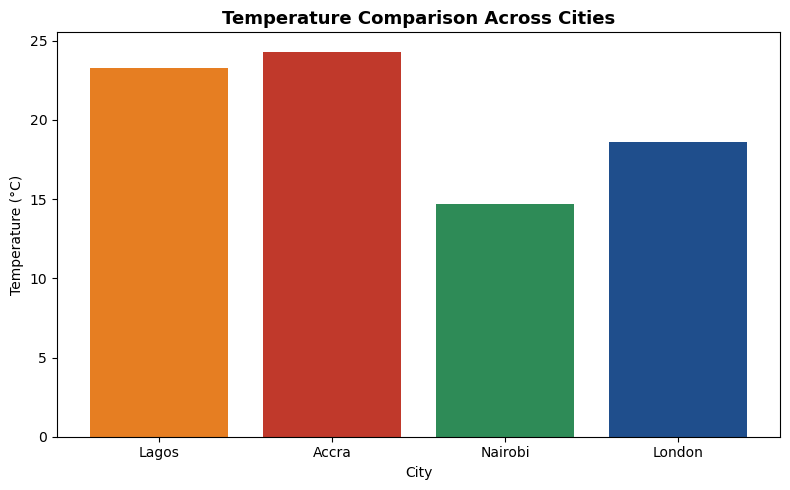

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
colors_list = ["#e67e22", "#c0392b", "#2e8b57","#1f4e8c"]

ax.bar(weather_df["City"], weather_df["Temperature_C"], color=colors_list)
ax.set_title("Temperature Comparison Across Cities", fontsize=13, fontweight="bold")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("City")
plt.tight_layout()
plt.show()

## Key Findings

- **Hottest city:** Accra at 24.31°C
- **Coldest city:** Nairobi at 14.70°C — a difference of nearly 10°C between the two, despite both being African cities, showing how much elevation and regional climate affect temperature.
- **Most humid city:** Lagos at 93% humidity, paired with "overcast clouds" — consistent with its coastal, tropical climate.
- **Weather conditions varied** across all 4 cities: overcast clouds (Lagos), broken clouds (Accra, Nairobi), and clear sky (London) — showing genuinely different live weather systems at the moment of collection.
- This snapshot reflects real-time conditions only; a longer-running pipeline (collecting data daily/hourly) would reveal actual climate trends rather than a single point-in-time comparison.